# EDA: RecSys Competition Dataset

ФИО: Никитченко Мария Владиславовна

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR = Path("hse-26-rec-sys-course-competition")

train = pd.read_parquet(DATA_DIR / "train.pq")
items = pd.read_parquet(DATA_DIR / "items.pq")
test_users = pd.read_csv(DATA_DIR / "test_users.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("train:", train.shape)
print("items:", items.shape)
print("test_users:", test_users.shape)
print("sample_submission:", sample_sub.shape)

train: (11373426, 6)
items: (34323, 4)
test_users: (185282, 1)
sample_submission: (3705640, 2)


## 1. Структура данных

In [2]:
print("=== train.pq ===")
print(train.dtypes)
print()
train.head(3)

=== train.pq ===
user_id                  int64
item_id                  int64
is_purchased              bool
rating                   int64
timestamp       datetime64[us]
impressions             object
dtype: object



,user_id,item_id,is_purchased,rating,timestamp,impressions
0,324824,18327,True,4,2014-05-15 12:27:08,"[18904, 24061, 27026, 28728, 28878, 27370, 183..."
1,116285,22214,False,0,2014-05-15 12:27:20,"[7626, 15860, 13908, 9968, 9702, 18901, 19103,..."
2,64299,31070,True,5,2014-05-15 12:27:20,"[20402, 32052, 29601, 11623, 22715, 4500, 5520..."


In [3]:
print("=== items.pq ===")
print(items.dtypes)
print()
items.head(3)

=== items.pq ===
item_id           int64
category_tags    object
series_id        object
author_ids       object
dtype: object



,item_id,category_tags,series_id,author_ids
0,5114,"[166918, 175145, 50357, 186689, 63050, 34286, ...","[2480, 13423, 13449, 783]",[9277]
1,28709,"[166918, 153826, 47635, 183297, 153869, 18044,...",[11007],[5779]
2,14357,"[166918, 186689, 183297, 56766, 56660, 50357, ...",[13388],"[5906, 11935]"


In [4]:
n_users = train['user_id'].nunique()
n_items_train = train['item_id'].nunique()
n_items_catalog = items['item_id'].nunique()
n_interactions = len(train)
n_test = test_users['user_id'].nunique()

density = n_interactions / (n_users * n_items_train)

print(f"Уникальных пользователей в train:    {n_users:,}")
print(f"Уникальных айтемов в train:          {n_items_train:,}")
print(f"Уникальных айтемов в каталоге:       {n_items_catalog:,}")
print(f"Всего взаимодействий:                {n_interactions:,}")
print(f"Пользователей в test:                {n_test:,}")
print(f"Плотность матрицы user-item:         {density:.6%}")
print()

# айтемы из каталога, которых нет в train
cold_items = set(items['item_id']) - set(train['item_id'])
print(f"Cold items (нет в train):            {len(cold_items):,} / {n_items_catalog:,} ({len(cold_items)/n_items_catalog:.1%})")

# тест-юзеры, которых нет в train
cold_users = set(test_users['user_id']) - set(train['user_id'])
print(f"Cold users (нет в train):            {len(cold_users):,} / {n_test:,} ({len(cold_users)/n_test:.1%})")

Уникальных пользователей в train:    348,111
Уникальных айтемов в train:          31,221
Уникальных айтемов в каталоге:       34,323
Всего взаимодействий:                11,373,426
Пользователей в test:                185,282
Плотность матрицы user-item:         0.104647%

Cold items (нет в train):            3,102 / 34,323 (9.0%)
Cold users (нет в train):            0 / 185,282 (0.0%)


__Выводы:__

Есть холодные айтемы в items.pq (9%, 3102 шт) — они есть в каталоге, но никто с ними не взаимодействовал. Использовать как отрицательные взаимодействия нельзя — у них нет никаких данных. Стратегия: content-based fallback через `category_tags` и `author_ids` если их нужно включить в рекомендации.

В тестовых данных нет холодных юзеров, для всех пользователей есть история взаимодействий.

## 2. Временной диапазон и активность

Временной диапазон: 2014-05-15 12:27:08 → 2016-12-10 02:40:09
Длительность:       939 дней


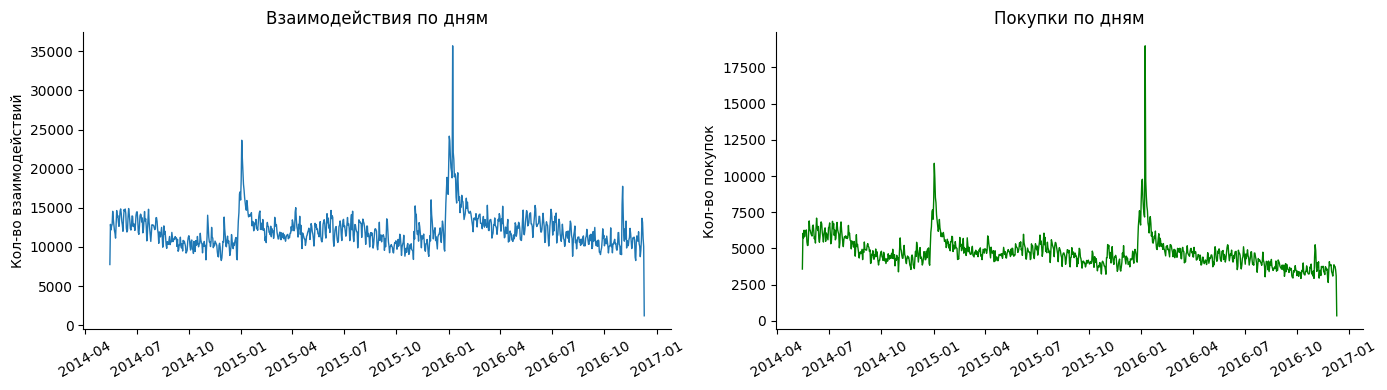

In [5]:
train['timestamp'] = pd.to_datetime(train['timestamp'])

print(f"Временной диапазон: {train['timestamp'].min()} → {train['timestamp'].max()}")
print(f"Длительность:       {(train['timestamp'].max() - train['timestamp'].min()).days} дней")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# активность по дням
daily = train.set_index('timestamp').resample('D').size()
axes[0].plot(daily.index, daily.values, linewidth=1)
axes[0].set_title('Взаимодействия по дням')
axes[0].set_ylabel('Кол-во взаимодействий')
axes[0].tick_params(axis='x', rotation=30)

# покупки по дням
daily_purchases = train[train['is_purchased']].set_index('timestamp').resample('D').size()
axes[1].plot(daily_purchases.index, daily_purchases.values, color='green', linewidth=1)
axes[1].set_title('Покупки по дням')
axes[1].set_ylabel('Кол-во покупок')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

__Выводы:__

Данные за два года. Видим четкую сезонность на новый год, это можно использовать - например видим, что сейчас у нас должен быть скоро новй год (на момент конца истории из данных), т.е. можно рекомендовать новогодние товары. Те, которые активно покупали в те же периоды в прошлый годы.

## 3. Сигналы: покупки и рейтинги

Покупки:           4,456,326  (39.2%)
Просмотры (нет покупки): 6,917,100  (60.8%)

Поведенческие сценарии:
  viewed                     6,917,100  (60.8%)
  bought_rated               4,105,065  (36.1%)
  bought_no_rating             351,261  (3.1%)


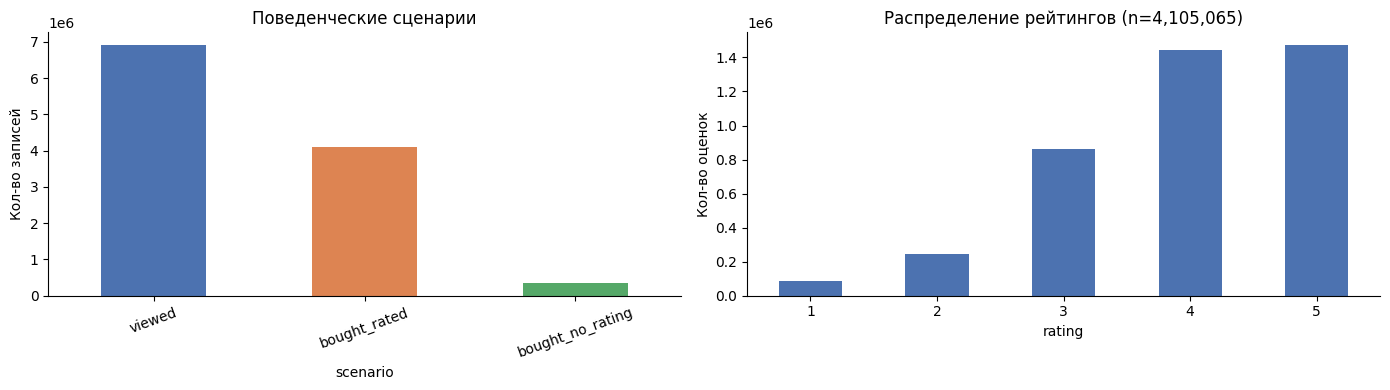

In [6]:
purchased = train['is_purchased'].sum()
viewed_only = (~train['is_purchased']).sum()
print(f"Покупки:           {purchased:,}  ({purchased/len(train):.1%})")
print(f"Просмотры (нет покупки): {viewed_only:,}  ({viewed_only/len(train):.1%})")
print()

# Поведенческие сценарии
train['scenario'] = 'viewed'
train.loc[train['is_purchased'] & (train['rating'] == 0), 'scenario'] = 'bought_no_rating'
train.loc[train['is_purchased'] & (train['rating'] > 0), 'scenario'] = 'bought_rated'
train.loc[~train['is_purchased'] & (train['rating'] > 0), 'scenario'] = 'viewed_rated'

sc = train['scenario'].value_counts()
print("Поведенческие сценарии:")
for name, cnt in sc.items():
    print(f"  {name:<25} {cnt:>10,}  ({cnt/len(train):.1%})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sc.plot(kind='bar', ax=axes[0], color=['#4c72b0','#dd8452','#55a868','#c44e52'])
axes[0].set_title('Поведенческие сценарии')
axes[0].set_ylabel('Кол-во записей')
axes[0].tick_params(axis='x', rotation=20)

# распределение рейтингов (только где rating > 0)
rated = train[train['rating'] > 0]
rated['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#4c72b0')
axes[1].set_title(f'Распределение рейтингов (n={len(rated):,})')
axes[1].set_ylabel('Кол-во оценок')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

__Выводы:__

В основном во взаимодейтсвиях просмотры, но и покупок достаточно много - 40%. Большинство юзеров после покупки оставляют отзывы. То есть отстутствие отзыва можно учитывать как сигнал.

В основоном отзывы положительные, отрицательные отзывы также важные сигналы.


## 4. Popular Bias: распределение активности по пользователям и айтемам

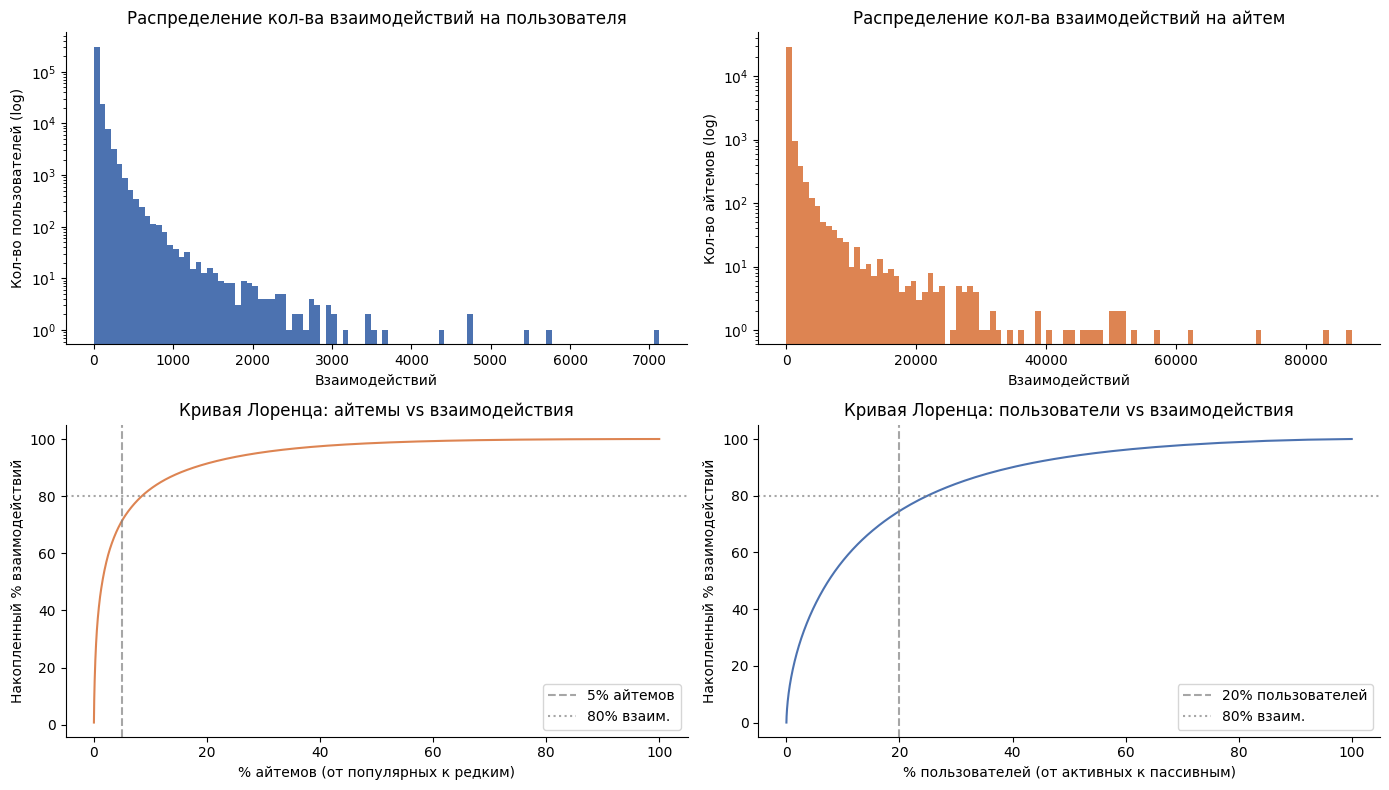

Топ 1% айтемов (312 шт) → 43.3% взаимодействий
Топ 5% айтемов (1,561 шт) → 71.5% взаимодействий

Айтемы в train без единой покупки: 2,104 / 31,221 (6.7%)


In [7]:
user_activity = train.groupby('user_id').size().sort_values(ascending=False)
item_activity = train.groupby('item_id').size().sort_values(ascending=False)
item_purchases = train[train['is_purchased']].groupby('item_id').size().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Распределение активности пользователей (log scale)
axes[0, 0].hist(user_activity.values, bins=100, color='#4c72b0', edgecolor='none')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Распределение кол-ва взаимодействий на пользователя')
axes[0, 0].set_xlabel('Взаимодействий')
axes[0, 0].set_ylabel('Кол-во пользователей (log)')

# Распределение активности айтемов (log scale)
axes[0, 1].hist(item_activity.values, bins=100, color='#dd8452', edgecolor='none')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Распределение кол-ва взаимодействий на айтем')
axes[0, 1].set_xlabel('Взаимодействий')
axes[0, 1].set_ylabel('Кол-во айтемов (log)')

# Cumulative: топ-N% айтемов → X% взаимодействий
item_cumshare = item_activity.cumsum() / item_activity.sum()
pct_items = np.arange(1, len(item_cumshare) + 1) / len(item_cumshare) * 100
axes[1, 0].plot(pct_items, item_cumshare.values * 100, color='#dd8452')
axes[1, 0].axvline(5, color='gray', linestyle='--', alpha=0.7, label='5% айтемов')
axes[1, 0].axhline(80, color='gray', linestyle=':', alpha=0.7, label='80% взаим.')
axes[1, 0].set_title('Кривая Лоренца: айтемы vs взаимодействия')
axes[1, 0].set_xlabel('% айтемов (от популярных к редким)')
axes[1, 0].set_ylabel('Накопленный % взаимодействий')
axes[1, 0].legend()

# Cumulative: топ-N% пользователей → X% взаимодействий
user_cumshare = user_activity.cumsum() / user_activity.sum()
pct_users = np.arange(1, len(user_cumshare) + 1) / len(user_cumshare) * 100
axes[1, 1].plot(pct_users, user_cumshare.values * 100, color='#4c72b0')
axes[1, 1].axvline(20, color='gray', linestyle='--', alpha=0.7, label='20% пользователей')
axes[1, 1].axhline(80, color='gray', linestyle=':', alpha=0.7, label='80% взаим.')
axes[1, 1].set_title('Кривая Лоренца: пользователи vs взаимодействия')
axes[1, 1].set_xlabel('% пользователей (от активных к пассивным)')
axes[1, 1].set_ylabel('Накопленный % взаимодействий')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Конкретные цифры popular bias
top5_items = int(len(item_activity) * 0.05)
top1_items = int(len(item_activity) * 0.01)
print(f"Топ 1% айтемов ({top1_items:,} шт) → {item_activity.iloc[:top1_items].sum() / item_activity.sum():.1%} взаимодействий")
print(f"Топ 5% айтемов ({top5_items:,} шт) → {item_activity.iloc[:top5_items].sum() / item_activity.sum():.1%} взаимодействий")
print()
# айтемы с 0 покупками
never_bought = set(train['item_id']) - set(item_purchases.index)
print(f"Айтемы в train без единой покупки: {len(never_bought):,} / {n_items_train:,} ({len(never_bought)/n_items_train:.1%})")

__Выводы:__

Классическая ситуация для маркетплейса, 5% товаров берут на себя большую часть взаимодействий, а также 20% пользователей самые активные.

Айтемом которые вообще никто не покупает достаточно мало, их также можно использовать для отрицательных примеров и не стоит рекомендовать.

## 5. CTR из поля impressions

In [8]:
# Проверяем формат impressions
print("Тип impressions:", type(train['impressions'].iloc[0]))
print("Пример:", train['impressions'].iloc[0])
print("Длина слейта:", len(train['impressions'].iloc[0]) if train['impressions'].iloc[0] is not None else "None")
print()

# Проверка: item_id всегда входит в impressions?
sample = train.head(1000).copy()
sample['item_in_impressions'] = sample.apply(
    lambda r: r['item_id'] in r['impressions'] if r['impressions'] is not None else None, axis=1
)
print(f"item_id входит в impressions: {sample['item_in_impressions'].mean():.1%} (выборка 1000 записей)")
print()

# Позиция айтема в слейте (position bias)
def get_position(row):
    try:
        return list(row['impressions']).index(row['item_id'])
    except (ValueError, TypeError):
        return -1

sample['position'] = sample.apply(get_position, axis=1)
pos_clicks = sample[sample['position'] >= 0].groupby('position').size()
print("Распределение позиций выбранных айтемов в слейте (первые 20):")
print(pos_clicks.head(20))

Тип impressions: <class 'numpy.ndarray'>
Пример: [18904 24061 27026 28728 28878 27370 18327 33827 14996 15323  4003 29697
  1921 32081  7396 14961 26487 22493  2823 12578]
Длина слейта: 20

item_id входит в impressions: 100.0% (выборка 1000 записей)

Распределение позиций выбранных айтемов в слейте (первые 20):
position
0     53
1     55
2     54
3     45
4     50
5     46
6     43
7     59
8     51
9     53
10    56
11    45
12    50
13    55
14    49
15    52
16    44
17    49
18    39
19    52
dtype: int64


Айтемов с данными о показах: 31,221

CTR статистика:
count    31221.0000
mean         0.0442
std          0.0038
min          0.0256
25%          0.0428
50%          0.0440
75%          0.0452
max          0.1000
Name: ctr, dtype: float64


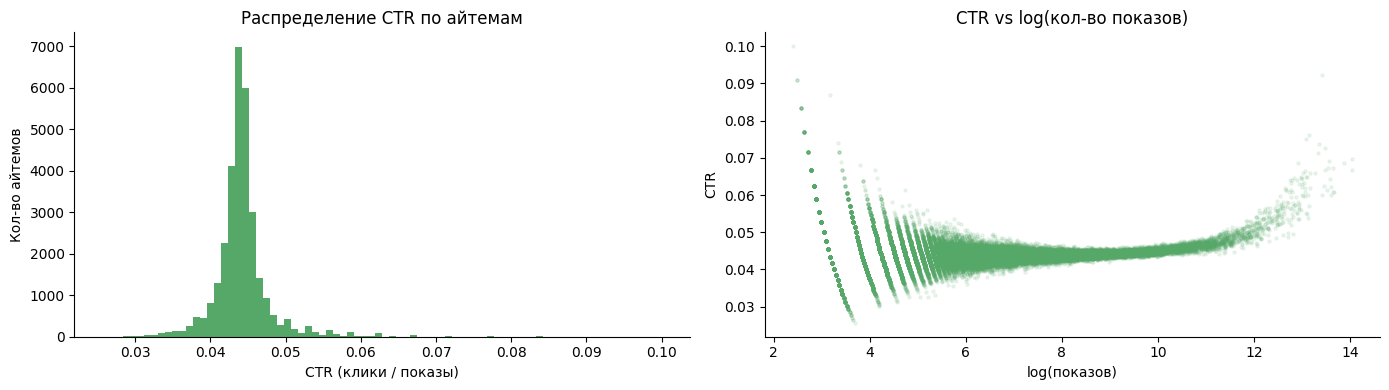

In [9]:
# CTR на уровне айтема: показов в impressions vs кликов
# Разворачиваем impressions → кол-во показов каждого айтема
from collections import Counter

impression_counts = Counter()
for imp_list in train['impressions'].dropna():
    impression_counts.update(imp_list)

imp_series = pd.Series(impression_counts, name='impressions_count')
click_series = train.groupby('item_id').size().rename('clicks')

ctr_df = pd.concat([imp_series, click_series], axis=1).dropna()
ctr_df['ctr'] = ctr_df['clicks'] / ctr_df['impressions_count']

print(f"Айтемов с данными о показах: {len(ctr_df):,}")
print(f"\nCTR статистика:")
print(ctr_df['ctr'].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(ctr_df['ctr'].clip(0, 1), bins=80, color='#55a868', edgecolor='none')
axes[0].set_title('Распределение CTR по айтемам')
axes[0].set_xlabel('CTR (клики / показы)')
axes[0].set_ylabel('Кол-во айтемов')

axes[1].scatter(np.log1p(ctr_df['impressions_count']), ctr_df['ctr'],
                alpha=0.1, s=5, color='#55a868')
axes[1].set_title('CTR vs log(кол-во показов)')
axes[1].set_xlabel('log(показов)')
axes[1].set_ylabel('CTR')

plt.tight_layout()
plt.show()

__Выводы:__

Айтемы в данных всегда есть в своих слейтах (100%) — данные чистые.

Позиция айтема в слейте не важна: распределение равномерное по всем 20 позициям — слейты рандомизированы.

CTR использовать нельзя даже в сглаженном виде: mean=0.044, std=0.004 — дисперсия почти нулевая, все айтемы имеют практически одинаковый CTR. Фича не несёт дискриминирующего сигнала.

Единственная польза от `impressions` — источник **неявных негативов**: айтемы в слейте, которые не были кликнуты, можно использовать как негативные примеры при обучении.

## 6. Каталог товаров: категории, авторы, серии

In [10]:
print("items.pq — первые 5 строк:")
display(items.head())
print()

# Длины списков
for col in ['category_tags', 'series_id', 'author_ids']:
    lengths = items[col].dropna().apply(len)
    n_empty = (lengths == 0).sum()
    n_null = items[col].isna().sum()
    print(f"{col}:")
    print(f"  null: {n_null}, пустых []: {n_empty}, среднее кол-во: {lengths[lengths>0].mean():.1f}, макс: {lengths.max()}")
    print()

items.pq — первые 5 строк:


,item_id,category_tags,series_id,author_ids
0,5114,"[166918, 175145, 50357, 186689, 63050, 34286, ...","[2480, 13423, 13449, 783]",[9277]
1,28709,"[166918, 153826, 47635, 183297, 153869, 18044,...",[11007],[5779]
2,14357,"[166918, 186689, 183297, 56766, 56660, 50357, ...",[13388],"[5906, 11935]"
3,28469,"[166918, 50357, 93278, 186689, 56660, 56766, 3...",[],"[8558, 11205, 8989, 8499, 659, 1182, 2492, 741..."
4,12537,"[166918, 50357, 183297, 186689, 22178, 22341, ...",[],[6721]



category_tags:
  null: 0, пустых []: 0, среднее кол-во: 80.6, макс: 438

series_id:
  null: 0, пустых []: 14737, среднее кол-во: 1.1, макс: 4

author_ids:
  null: 0, пустых []: 0, среднее кол-во: 1.3, макс: 52



In [11]:
# Кол-во уникальных тегов/авторов/серий
from itertools import chain

def count_unique(col):
    return len(set(chain.from_iterable(items[col].dropna())))

print(f"Уникальных category_tags: {count_unique('category_tags'):,}")
print(f"Уникальных series_id:     {count_unique('series_id'):,}")
print(f"Уникальных author_ids:    {count_unique('author_ids'):,}")
print()

# Покрытие: у скольких айтемов из каталога есть авторы/серии
for col in ['category_tags', 'series_id', 'author_ids']:
    has_data = items[col].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) > 0).sum()
    print(f"Айтемы с непустым {col}: {has_data:,} / {len(items):,} ({has_data/len(items):.1%})")

Уникальных category_tags: 189,697
Уникальных series_id:     15,302
Уникальных author_ids:    16,445

Айтемы с непустым category_tags: 34,323 / 34,323 (100.0%)
Айтемы с непустым series_id: 19,586 / 34,323 (57.1%)
Айтемы с непустым author_ids: 34,323 / 34,323 (100.0%)


__Выводы:__

Категория и автор есть у всех айтемов в каталоге, это будут важные признаки. Серия есть у половины, но также можно использовать.

## 7. Активность пользователей: cold users в тесте и длины историй

Статистика по кол-ву взаимодействий у тест-пользователей:
count    185282.0
mean         48.6
std         104.0
min           1.0
25%           6.0
50%          18.0
75%          53.0
max        7123.0
dtype: float64

Распределение тест-пользователей по активности:
cold (0)              0
very_low (1-5)    43205
low (6-20)        54117
medium (21-50)    39946
high (50+)        48014
Name: count, dtype: int64


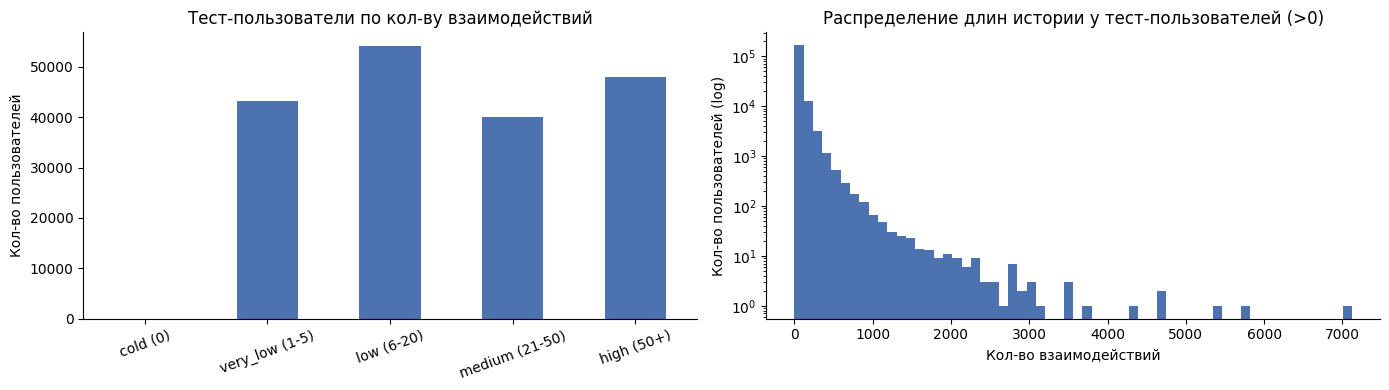

In [12]:
test_user_activity = user_activity.reindex(test_users['user_id']).fillna(0)

print("Статистика по кол-ву взаимодействий у тест-пользователей:")
print(test_user_activity.describe().round(1))
print()

# Бакеты по активности
buckets = pd.cut(test_user_activity, bins=[-1, 0, 5, 20, 50, float('inf')],
                 labels=['cold (0)', 'very_low (1-5)', 'low (6-20)', 'medium (21-50)', 'high (50+)'])
print("Распределение тест-пользователей по активности:")
print(buckets.value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

buckets.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4c72b0')
axes[0].set_title('Тест-пользователи по кол-ву взаимодействий')
axes[0].set_ylabel('Кол-во пользователей')
axes[0].tick_params(axis='x', rotation=20)

train_activity_test_users = test_user_activity[test_user_activity > 0]
axes[1].hist(train_activity_test_users.values, bins=60, color='#4c72b0', edgecolor='none')
axes[1].set_yscale('log')
axes[1].set_title('Распределение длин истории у тест-пользователей (>0)')
axes[1].set_xlabel('Кол-во взаимодействий')
axes[1].set_ylabel('Кол-во пользователей (log)')

plt.tight_layout()
plt.show()

__Выводы:__

Холодных юзеров нет. При этом 23% тест-пользователей имеют только 1–5 взаимодействий — для них CF-модели будут давать слабые рекомендации из-за недостатка данных. TopPop как fallback для low-activity пользователей всё равно нужен. Полностью отказываться от бэйзлайн-стратегии не стоит.

## 8. Пересечение train / test по айтемам и overlap покупок

In [13]:
# Повторные покупки: пользователь купил один и тот же айтем несколько раз?
repeat_purchases = (
    train[train['is_purchased']]
    .groupby(['user_id', 'item_id'])
    .size()
    .reset_index(name='n')
)
print(f"Уникальных (user, item) покупок: {len(repeat_purchases):,}")
print(f"Из них повторные (n > 1): {(repeat_purchases['n'] > 1).sum():,} ({(repeat_purchases['n'] > 1).mean():.2%})")
print()

# Перекрытие: покупали ли тест-пользователи одни и те же айтемы?
test_user_set = set(test_users['user_id'])
test_train = train[train['user_id'].isin(test_user_set)]
test_purchases = test_train[test_train['is_purchased']]['item_id'].nunique()
print(f"Тест-пользователи уже купили {test_purchases:,} уникальных айтемов в train")
print("→ Эти айтемы нужно исключать из рекомендаций (already bought filter)")
print()

# Среднее кол-во уже купленных айтемов на тест-пользователя
test_bought_per_user = (
    test_train[test_train['is_purchased']]
    .groupby('user_id')['item_id']
    .nunique()
)
print(f"Среднее кол-во купленных айтемов на тест-пользователя: {test_bought_per_user.mean():.1f}")
print(f"Медиана: {test_bought_per_user.median():.0f}, макс: {test_bought_per_user.max()}")

Уникальных (user, item) покупок: 4,456,326
Из них повторные (n > 1): 0 (0.00%)

Тест-пользователи уже купили 28,298 уникальных айтемов в train
→ Эти айтемы нужно исключать из рекомендаций (already bought filter)

Среднее кол-во купленных айтемов на тест-пользователя: 20.2
Медиана: 10, макс: 1793


__Выводы:__
Видимо наши пользователи не любят покупать что-то второй раз на этом маркетплейсе, видимо товары что-то вроде книги или диски - второй раз одно и то же покупать не будут. 

Значит, важно рекомендовать что-то похожее по контенту. Обязательно удалить из рекомендаций для пользователя то, что они уже покупали.